In [1]:
# --- Imports / path setup (match your script) ---
import sys
from pathlib import Path
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

from src.behavior_import.import_data import *
from src.behavior_import.extract_trials import *
from src.behavior_analysis.get_total_reversals import *
from src.behavior_analysis.get_good_reversal_info import *
from src.behavior_analysis.get_choice_probs_around_good_reversals import *
from src.behavior_analysis.split_good_reversals_by_best_change import *
from src.behavior_analysis.split_early_late_good_reversals import *
from src.behavior_visualization.plot_choice_probs_around_good_reversals import *

In [2]:
task = "open-field"
cohort = "cohort-01"
folder_name = "3x3_field_blocked_reward_bandit"

root = f"/Volumes/behrens/meg/{folder_name}/{cohort}/rawdata/"
subjects_data = import_data(root)
subjects_trials_by_problem = extract_trials_grouped_by_problem(subjects_data)

[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-01_id-MY_71_N/ses-08_date-20260204/behav/._MY_71_N-2026-02-04-153602.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-02_id-MY_71_L/ses-54_date-20260305/behav/._MY_71_L-2026-03-05-150416.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-04_id-MY_72_N/ses-40_date-20260225/behav/._MY_72_N-2026-02-25-143929.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-04_id-MY_72_N/ses-39_date-20260225/behav/._MY_72_N-2026-02-25-103701.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /V

In [3]:
subject_trials_by_value_problem = {}
for problem_number in subjects_trials_by_problem.keys():
    problem = f"problem-{problem_number:02d}"
    if problem_number >= 5:
        subjects_trials = subjects_trials_by_problem[problem_number]
        subject_trials_by_value_problem[problem_number] = subjects_trials

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

BEST_VALS = [2, 3, 4]       # y-axis
SECOND_VALS = [1, 2, 3]     # x-axis

def init_matrix(fill=np.nan):
    return pd.DataFrame(
        fill,
        index=pd.Index(BEST_VALS, name="best_value"),
        columns=pd.Index(SECOND_VALS, name="second_value"),
    )

def _compute_believed_trials(choices, chosen_ranks, reward_magnitudes):
    """
    For each trial i, infer:
      - The believed magnitude for every arm (last observed value before trial i).
      - The believed rank of the chosen arm, derived by re-ranking all arms by
        their believed magnitudes.
      - The believed best and second-best magnitudes (by believed rank order).

    Arms with no prior visits are excluded (believed value = None), and any
    trial where at least one arm has no believed value is skipped (returns None
    for that trial).

    Parameters
    ----------
    choices           : list[str]   — arm chosen on each trial
    chosen_ranks      : list[str]   — true rank of chosen arm ("best"/"second"/"third")
    reward_magnitudes : list[dict]  — true arm->magnitude mapping per trial

    Returns
    -------
    list of (believed_best_mag, believed_second_mag, believed_chosen_rank) | None
      None means the trial should be excluded.
      believed_chosen_rank is "best"/"second"/"third" based on believed ordering.
    """
    last_seen = {}  # arm -> magnitude last observed when chosen
    results = []

    for i, rm in enumerate(reward_magnitudes):
        choice = choices[i]
        all_arms = list(rm.keys())

        # Build believed magnitudes for all arms; skip trial if any arm unseen
        believed = {}
        skip = False
        for arm in all_arms:
            if arm not in last_seen:
                skip = True
                break
            believed[arm] = last_seen[arm]

        if skip:
            results.append(None)
        else:
            # Re-rank arms by believed magnitude (descending)
            ranked = sorted(believed.items(), key=lambda x: x[1], reverse=True)
            believed_best_mag   = ranked[0][1] if len(ranked) > 0 else None
            believed_second_mag = ranked[1][1] if len(ranked) > 1 else None

            # Determine believed rank of the chosen arm
            believed_rank_of_choice = None
            for rank_idx, (arm, mag) in enumerate(ranked):
                if arm == choice:
                    believed_rank_of_choice = ["best", "second", "third"][min(rank_idx, 2)]
                    break

            if believed_best_mag is None or believed_second_mag is None or believed_rank_of_choice is None:
                results.append(None)
            elif believed_best_mag == believed_second_mag:  # tie — exclude
                results.append(None)
            else:
                results.append((believed_best_mag, believed_second_mag, believed_rank_of_choice))

        # Update last_seen AFTER recording (current choice counts for future trials only)
        if choice and choice in rm:
            last_seen[choice] = rm[choice]

    return results

def accumulate_choice_probs(subject_trials_by_value_problem, use_believed=False):
    """
    subject_trials_by_value_problem[problem][subject_id][session_id] = session_data

    session_data["trial_variables"] is a list with a single element: a dict of
    parallel lists, one value per trial. Keys include:
      - "reward_magnitudes" : list[dict]  — arm->magnitude per trial
      - "chosen_rank"       : list[str]   — "best"/"second"/"third" per trial
      - "choice"            : list[str]   — chosen arm label per trial

    Parameters
    ----------
    use_believed : bool
        False (default) — bin by true reward magnitudes and true chosen rank.
        True            — bin by believed magnitudes (last observed value per arm
                          before this trial), with arms re-ranked by believed
                          value to determine best/second and the chosen rank.
                          Trials where any arm has never been visited are excluded.

    Returns
    -------
    overall_best_prob_df   : 3×3 DataFrame  (nanmean across mice)
    overall_second_prob_df : 3×3 DataFrame
    per_mouse_best_prob    : dict[subject_id -> 3×3 DataFrame]
    per_mouse_second_prob  : dict[subject_id -> 3×3 DataFrame]
    """
    denom_mouse      = {}
    num_best_mouse   = {}
    num_second_mouse = {}

    def ensure_mouse(sid):
        if sid not in denom_mouse:
            denom_mouse[sid]      = init_matrix(fill=0.0)
            num_best_mouse[sid]   = init_matrix(fill=0.0)
            num_second_mouse[sid] = init_matrix(fill=0.0)

    for problem_num, subjects_dict in subject_trials_by_value_problem.items():
        for subject_id, sessions_dict in subjects_dict.items():
            ensure_mouse(subject_id)

            for session_id, sess in sessions_dict.items():
                tv_list = sess.get("trial_variables", [])
                if not tv_list:
                    continue
                tv = tv_list[0]  # single dict of parallel lists

                reward_magnitudes = tv.get("reward_magnitudes", [])
                chosen_ranks      = tv.get("chosen_rank", [])
                choices           = tv.get("choice", [])

                n = min(len(reward_magnitudes), len(chosen_ranks), len(choices))
                if n == 0:
                    continue

                if use_believed:
                    believed_trials = _compute_believed_trials(
                        choices[:n], chosen_ranks[:n], reward_magnitudes[:n]
                    )

                for i in range(n):
                    if use_believed:
                        trial = believed_trials[i]
                        if trial is None:
                            continue
                        b, s, chosen_rank = trial
                    else:
                        chosen_rank = chosen_ranks[i]
                        rm = reward_magnitudes[i]
                        sorted_arms = sorted(rm.items(), key=lambda x: x[1], reverse=True)
                        if len(sorted_arms) < 2:
                            continue
                        b = sorted_arms[0][1]
                        s = sorted_arms[1][1]

                    if chosen_rank not in ("best", "second", "third"):
                        continue
                    if b not in BEST_VALS or s not in SECOND_VALS:
                        continue

                    denom_mouse[subject_id].loc[b, s] += 1
                    if chosen_rank == "best":
                        num_best_mouse[subject_id].loc[b, s] += 1
                    elif chosen_rank == "second":
                        num_second_mouse[subject_id].loc[b, s] += 1

    # per-mouse probability matrices
    per_mouse_best_prob   = {}
    per_mouse_second_prob = {}
    for sid in denom_mouse:
        d = denom_mouse[sid]
        per_mouse_best_prob[sid]   = num_best_mouse[sid].divide(d.where(d > 0))
        per_mouse_second_prob[sid] = num_second_mouse[sid].divide(d.where(d > 0))

    # overall = nanmean across mice so every mouse contributes equally per cell
    def nanmean_matrices(prob_dict):
        if not prob_dict:
            return init_matrix(fill=np.nan)
        stack = np.stack([df.to_numpy(dtype=float) for df in prob_dict.values()], axis=0)
        ref   = next(iter(prob_dict.values()))
        return pd.DataFrame(np.nanmean(stack, axis=0), index=ref.index, columns=ref.columns)

    overall_best_prob   = nanmean_matrices(per_mouse_best_prob)
    overall_second_prob = nanmean_matrices(per_mouse_second_prob)

    return overall_best_prob, overall_second_prob, per_mouse_best_prob, per_mouse_second_prob

def plot_prob_heatmap(df, title, ax=None, vmin=0.0, vmax=1.0, annotate=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.6, 4.2))

    df = df.reindex(index=BEST_VALS, columns=SECOND_VALS)
    arr = np.flipud(df.to_numpy(dtype=float))  # flip so 2 is bottom, 4 is top

    im = ax.imshow(arr, vmin=vmin, vmax=vmax, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("Second Value")
    ax.set_ylabel("Best Value")
    ax.set_xticks(np.arange(len(SECOND_VALS)))
    ax.set_xticklabels(SECOND_VALS)
    ax.set_yticks(np.arange(len(BEST_VALS)))
    ax.set_yticklabels(list(reversed(BEST_VALS)))

    if annotate:
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                val = arr[i, j]
                txt = "NA" if np.isnan(val) else f"{val:.2f}"
                ax.text(j, i, txt, ha="center", va="center")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax

def plot_overall_heatmaps(overall_p_best, overall_p_second, annotate=True, use_believed=False):
    label = "Believed" if use_believed else "True"
    fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))
    plot_prob_heatmap(overall_p_best,
                      f"P(choose best) — {label} Value",
                      ax=axs[0], annotate=annotate)
    plot_prob_heatmap(overall_p_second,
                      f"P(choose second) — {label} Value",
                      ax=axs[1], annotate=annotate)
    plt.tight_layout()
    plt.show()

def plot_per_mouse_heatmaps(per_mouse_p_best, per_mouse_p_second, annotate=True,
                             mice=None, use_believed=False):
    """
    mice: optional list of subject_ids to plot; defaults to all keys in per_mouse_p_best.
    """
    label = "believed" if use_believed else "true"
    if mice is None:
        mice = sorted(per_mouse_p_best.keys())

    for subject_id in mice:
        fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))
        plot_prob_heatmap(per_mouse_p_best[subject_id],
                          f"P(choose best) — {subject_id} ({label} value)",
                          ax=axs[0], annotate=annotate)
        plot_prob_heatmap(per_mouse_p_second[subject_id],
                          f"P(choose second) — {subject_id} ({label} value)",
                          ax=axs[1], annotate=annotate)
        plt.tight_layout()
        plt.show()

/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/2636085226.py:182: RuntimeWarning: Mean of empty slice
  return pd.DataFrame(np.nanmean(stack, axis=0), index=ref.index, columns=ref.columns)


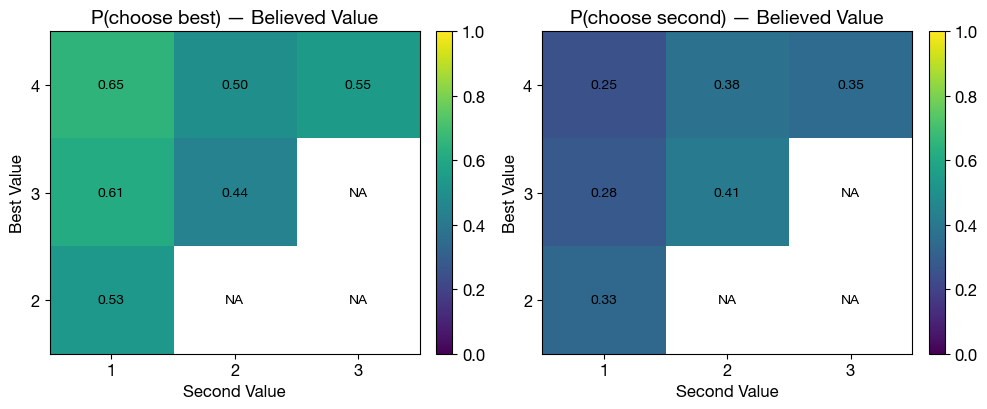

In [5]:
overall_best, overall_second, per_mouse_best, per_mouse_second = \
    accumulate_choice_probs(subject_trials_by_value_problem, use_believed=True)

plot_overall_heatmaps(overall_best, overall_second, annotate=True, use_believed=True)

/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/2636085226.py:182: RuntimeWarning: Mean of empty slice
  return pd.DataFrame(np.nanmean(stack, axis=0), index=ref.index, columns=ref.columns)


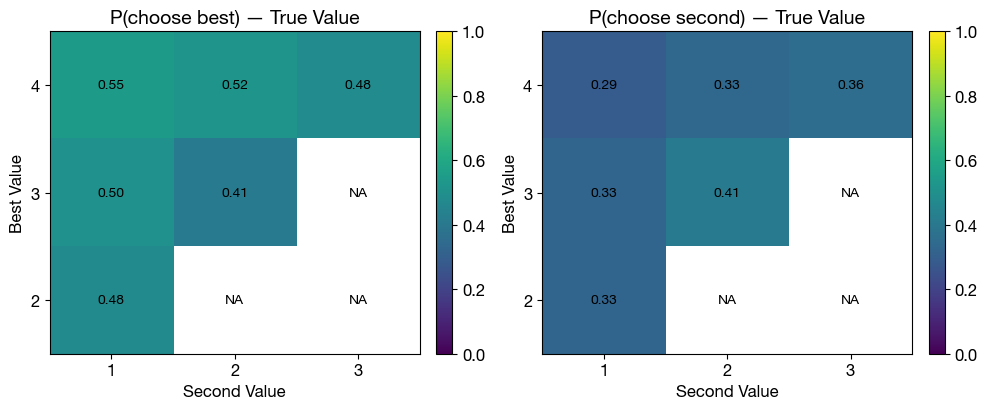

In [6]:
overall_best, overall_second, per_mouse_best, per_mouse_second = \
    accumulate_choice_probs(subject_trials_by_value_problem, use_believed=False)

plot_overall_heatmaps(overall_best, overall_second, annotate=True, use_believed=False)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

BEST_VALS   = [2, 3, 4]
SECOND_VALS = [1, 2, 3]


# ---------------------------------------------------------------------------
# Helper: collapse a per-mouse probability DataFrame into psychometric curves
# ---------------------------------------------------------------------------

def _psychometric_data(per_mouse_prob_best, per_mouse_prob_second):
    """
    From per-mouse 3×3 DataFrames, compute p(chosen) as a function of:
      - value of best arm          (averaged over second-best values)
      - value of second-best arm   (averaged over best values)
      - difference (best - second) (averaged over matching cells)

    Returns a dict with keys "best_val", "second_val", "diff", each mapping to:
      {
        "x"      : array of x-axis values,
        "mouse"  : 2-D array (n_mice × n_x) of per-mouse means (NaN where missing),
        "mean"   : 1-D array of grand mean across mice (nanmean),
      }
    for both "best" and "second" choice probabilities.
    """
    mice = sorted(per_mouse_prob_best.keys())
    n    = len(mice)

    def collect(per_mouse_prob, x_vals, y_vals, axis):
        """
        axis=0 → marginalise over second-best (x = best value)
        axis=1 → marginalise over best        (x = second value)
        """
        rows = []
        for sid in mice:
            df  = per_mouse_prob[sid].reindex(index=BEST_VALS, columns=SECOND_VALS)
            arr = df.to_numpy(dtype=float)          # shape (3, 3)
            row = np.nanmean(arr, axis=axis)         # shape (3,)
            rows.append(row)
        mat = np.array(rows)                         # (n_mice, 3)
        return {"x": np.array(x_vals), "mouse": mat,
                "mean": np.nanmean(mat, axis=0)}

    def collect_diff(per_mouse_prob):
        """
        x = best_val - second_val, averaged across cells with the same difference.
        Possible differences for BEST_VALS=[2,3,4], SECOND_VALS=[1,2,3]:
          1 (e.g. 2-1, 3-2, 4-3), 2 (3-1, 4-2), 3 (4-1)
        """
        diffs = sorted({b - s for b in BEST_VALS for s in SECOND_VALS if b > s})
        rows  = []
        for sid in mice:
            df  = per_mouse_prob[sid].reindex(index=BEST_VALS, columns=SECOND_VALS)
            arr = df.to_numpy(dtype=float)
            row = []
            for d in diffs:
                vals = [arr[bi, si]
                        for bi, b in enumerate(BEST_VALS)
                        for si, s in enumerate(SECOND_VALS)
                        if b - s == d]
                row.append(np.nanmean(vals) if vals else np.nan)
            rows.append(row)
        mat = np.array(rows)
        return {"x": np.array(diffs), "mouse": mat,
                "mean": np.nanmean(mat, axis=0)}

    return {
        "best": {
            "best_val":   collect(per_mouse_prob_best,   BEST_VALS,   SECOND_VALS, axis=1),
            "second_val": collect(per_mouse_prob_best,   SECOND_VALS, BEST_VALS,   axis=0),
            "diff":       collect_diff(per_mouse_prob_best),
        },
        "second": {
            "best_val":   collect(per_mouse_prob_second,   BEST_VALS,   SECOND_VALS, axis=1),
            "second_val": collect(per_mouse_prob_second,   SECOND_VALS, BEST_VALS,   axis=0),
            "diff":       collect_diff(per_mouse_prob_second),
        },
    }


# ---------------------------------------------------------------------------
# Core subplot painter
# ---------------------------------------------------------------------------

def _draw_psychometric(ax, data, xlabel, ylabel, title):
    """
    data : {"x": array, "mouse": (n_mice, n_x) array, "mean": (n_x,) array}
    """
    x    = data["x"]
    mat  = data["mouse"]
    mean = data["mean"]

    for i in range(mat.shape[0]):
        y = mat[i]
        mask = ~np.isnan(y)
        if mask.sum() >= 2:
            ax.plot(x[mask], y[mask], color="gray", lw=0.8, alpha=0.5)
        elif mask.sum() == 1:
            ax.plot(x[mask], y[mask], "o", color="gray", ms=3, alpha=0.5)

    mask = ~np.isnan(mean)
    if mask.sum() >= 2:
        ax.plot(x[mask], mean[mask], color="black", lw=2.2, zorder=5)
        ax.plot(x[mask], mean[mask], "o", color="black", ms=5, zorder=6)
    elif mask.sum() == 1:
        ax.plot(x[mask], mean[mask], "o", color="black", ms=6, zorder=6)

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0.25, 0.75)
    ax.set_xticks(x)
    ax.axhline(0.33, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)


# ---------------------------------------------------------------------------
# Public API
# ---------------------------------------------------------------------------

def plot_psychometric_curves(per_mouse_best_prob, per_mouse_second_prob,
                              use_believed=False):
    """
    Produce two figures, each with three subplots:a

    Figure 1 — P(choose best):
      subplot 1: vs. value of best arm
      subplot 2: vs. value of second-best arm
      subplot 3: vs. difference (best - second)

    Figure 2 — P(choose second best): same layout.

    Individual mice are thin gray lines; the cross-mouse mean is a thick black line.

    Parameters
    ----------
    per_mouse_best_prob   : dict[subject_id -> 3×3 DataFrame]
    per_mouse_second_prob : dict[subject_id -> 3×3 DataFrame]
    use_believed          : bool  — used only for figure title labelling
    """
    label = "believed value" if use_believed else "true value"
    data  = _psychometric_data(per_mouse_best_prob, per_mouse_second_prob)

    x_labels = {
        "best_val":   "Value of best arm",
        "second_val": "Value of second-best arm",
        "diff":       "Best − second-best value",
    }
    keys = ["best_val", "second_val", "diff"]

    for outcome, y_label, fig_title in [
        ("best",   "P(choose best)",        f"P(choose best) — {label}"),
        ("second", "P(choose second best)", f"P(choose second best) — {label}"),
    ]:
        fig, axs = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
        fig.suptitle(fig_title, fontsize=13, fontweight="bold")

        for ax, key in zip(axs, keys):
            _draw_psychometric(
                ax,
                data[outcome][key],
                xlabel=x_labels[key],
                ylabel=y_label if key == "best_val" else "",
                title=x_labels[key],
            )

        plt.tight_layout()
        plt.show()

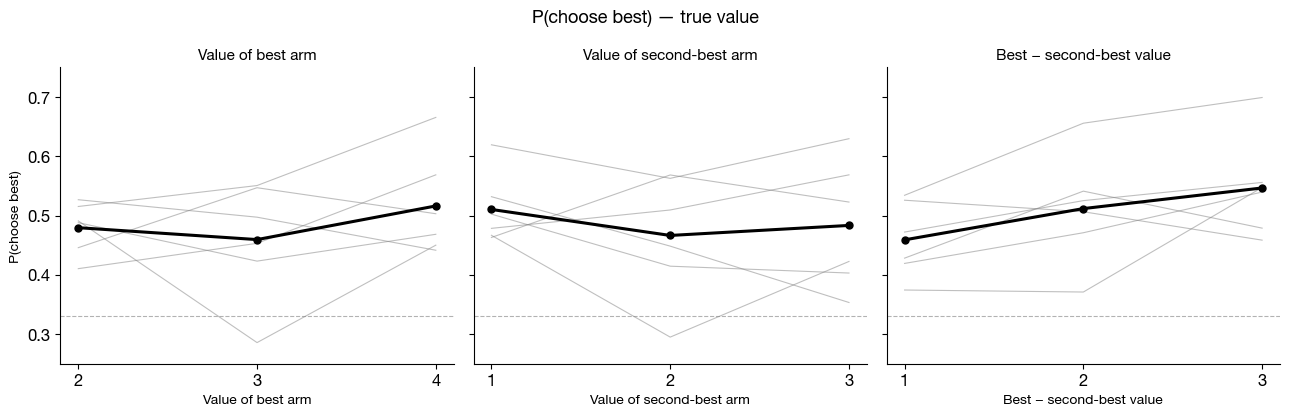

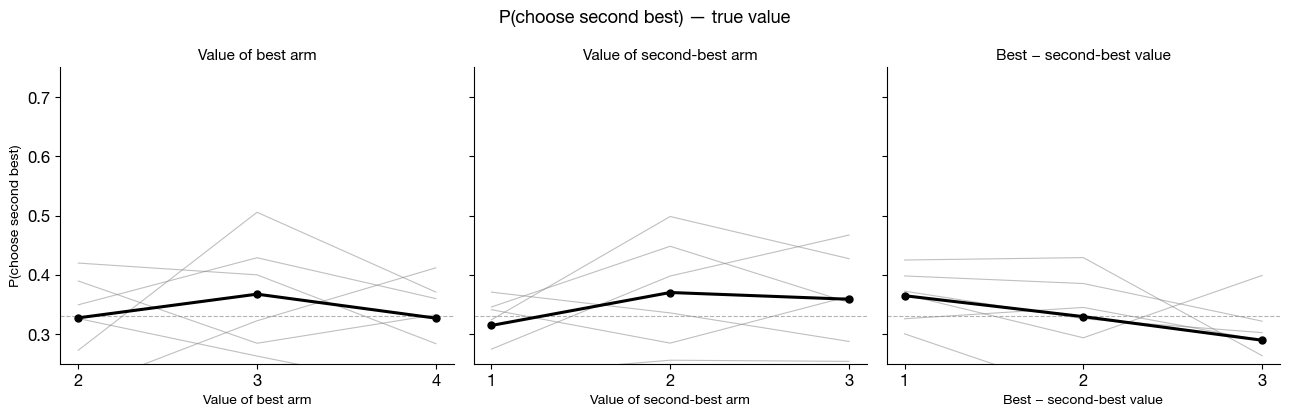

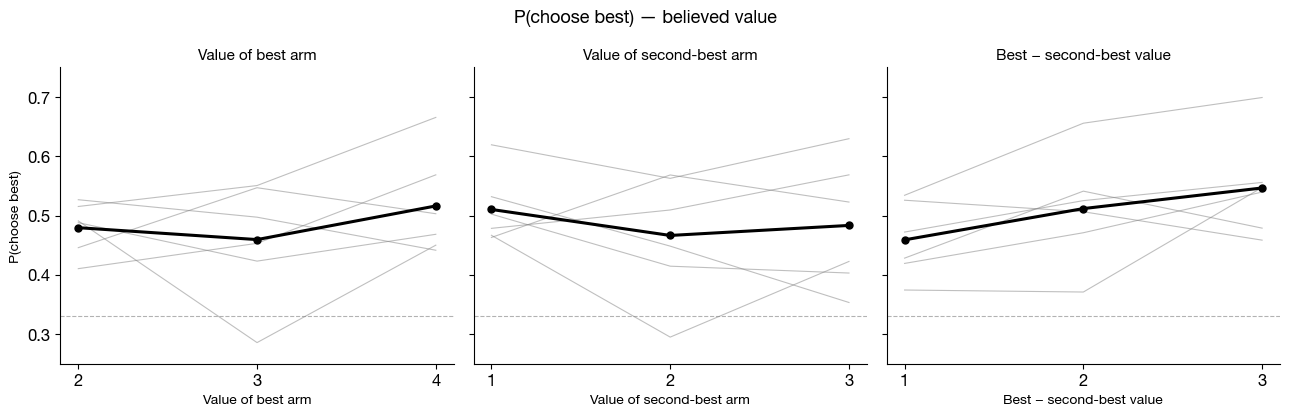

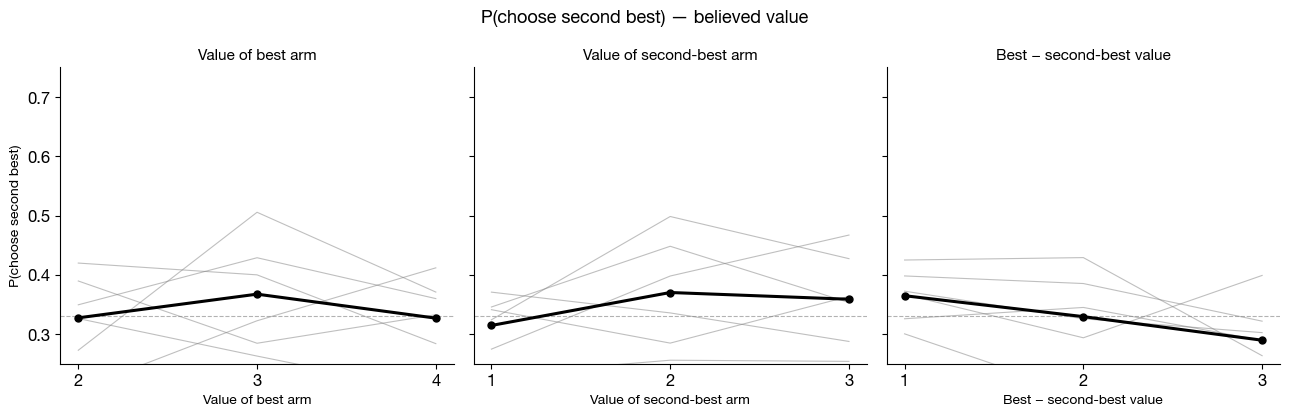

In [8]:
plot_psychometric_curves(per_mouse_best, per_mouse_second, use_believed=False)
plot_psychometric_curves(per_mouse_best, per_mouse_second, use_believed=True)

In [9]:
"""
reversal_analysis.py
====================
Reversal-aligned choice probability analysis with:
  - Secondary y-axis showing mean rank-1/2/3 magnitudes across reversals
  - Toggle for reversal type: "all", "best_to_third", "second_to_third"
  - Moving-average smoothing
  - Per-subject and across-subject aggregation

Public API
----------
    classify_reversal_type(reversal)
    filter_reversals_by_type(reversal_windows, reversal_type)
    get_choice_probs_around_good_reversals_prev_ranks(reversal_windows, pre, post, skip_n_trials_after_reversal)
    apply_moving_average(x, per_subject, window, mode, split_at)
    plot_reversal_choice_probs(x, per_subject, across, reversal_windows, reversal_type, use_moving_avg, ...)
"""

import warnings
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ---------------------------------------------------------------------------
# Style
# ---------------------------------------------------------------------------
mpl.rcParams["font.family"]      = "sans-serif"
mpl.rcParams["font.sans-serif"]  = ["Helvetica Neue", "Helvetica", "Arial"]
mpl.rcParams["xtick.labelsize"]  = 12
mpl.rcParams["ytick.labelsize"]  = 12
mpl.rcParams["axes.labelsize"]   = 12
mpl.rcParams["axes.titlesize"]   = 14

COLOR_MAP = {
    "prev_best":  "#5DA5DA",
    "prev_sec":   "#60BD68",
    "prev_third": "#7f7f7f",
}
LABEL_MAP = {
    "prev_best":  "Prev Best",
    "prev_sec":   "Prev Second",
    "prev_third": "Prev Third",
}
VALUE_COLOR_MAP = {
    "rank1": "#E05C5C",
    "rank2": "#E0A030",
}
VALUE_LABEL_MAP = {
    "rank1": "Best Value",
    "rank2": "Second Value",
}
PLOT_KEYS = ["prev_best", "prev_sec", "prev_third"]


# ---------------------------------------------------------------------------
# Reversal classification
# ---------------------------------------------------------------------------

def classify_reversal_type(reversal):
    """
    Determine whether a reversal is "best_to_third" or "second_to_third" by
    comparing rank orderings before and after the reversal.

    A reversal is "best_to_third"   if the pre-reversal best arm becomes third
    A reversal is "second_to_third" if the pre-reversal second arm becomes third
    Returns "other" if neither condition holds.

    Parameters
    ----------
    reversal : dict with keys:
        "reward_magnitudes_by_tower_before" : dict[tower -> magnitude]
        "reward_magnitudes_by_tower_after"  : dict[tower -> magnitude]

    Returns
    -------
    str : "best_to_third", "second_to_third", or "other"
    """
    before = reversal["reward_magnitudes_by_tower_before"]
    after  = reversal["reward_magnitudes_by_tower_after"]

    def rank_order(d):
        return [arm for arm, _ in sorted(d.items(), key=lambda kv: (-kv[1], str(kv[0])))]

    ranked_before = rank_order(before)
    ranked_after  = rank_order(after)

    if len(ranked_before) < 3 or len(ranked_after) < 3:
        return "other"

    prev_best  = ranked_before[0]
    prev_sec   = ranked_before[1]
    post_third = ranked_after[2]

    if prev_best == post_third:
        return "best_to_third"
    if prev_sec == post_third:
        return "second_to_third"
    return "other"


def filter_reversals_by_type(reversal_windows, reversal_type="all"):
    """
    Filter reversal_windows to only include reversals of the specified type.

    Parameters
    ----------
    reversal_windows : dict[subject_id -> list[reversal_dict]]
    reversal_type    : "all", "best_to_third", or "second_to_third"

    Returns
    -------
    dict[subject_id -> list[reversal_dict]]
    """
    if reversal_type == "all":
        return reversal_windows

    filtered = {}
    for subj, revs in reversal_windows.items():
        kept = [r for r in revs if classify_reversal_type(r) == reversal_type]
        if kept:
            filtered[subj] = kept
    return filtered


# ---------------------------------------------------------------------------
# Rank classification helper (unchanged from original)
# ---------------------------------------------------------------------------

def _classify_prev_ranks(reversal):
    before  = reversal["reward_magnitudes_by_tower_before"]
    ranked  = sorted(before.items(), key=lambda kv: (-kv[1], str(kv[0])))
    if len(ranked) < 3:
        raise ValueError(f"Need at least 3 towers; got {len(ranked)}")
    return ranked[0][0], ranked[1][0], ranked[2][0]   # prev_best, prev_sec, prev_third


# ---------------------------------------------------------------------------
# Magnitude extraction for secondary axis
# ---------------------------------------------------------------------------

def _compute_rank_magnitudes_over_time(reversal_windows, x):
    """
    For each trial offset in x, compute the mean ± SE of the rank-1 and rank-2
    magnitudes across all reversals and subjects, using per-trial magnitudes stored
    in "reward_magnitudes_by_rank_over_time" (added by enrich_reversal_windows_with_magnitudes).

    Falls back to static before/after dicts if the key is absent.

    Returns
    -------
    dict with keys "rank1" and "rank2", each mapping to:
        {"mean": array, "se": array}  both shape (len(x),)
    """
    x     = np.asarray(x, dtype=float)
    accum = {"rank1": [], "rank2": []}

    for subj, revs in reversal_windows.items():
        for r in revs:
            per_trial = r.get("reward_magnitudes_by_rank_over_time")

            if per_trial is not None:
                T = len(x)
                for key in ("rank1", "rank2"):
                    arr = np.asarray(per_trial[key], dtype=float)
                    # trim or pad to match x length
                    aligned = np.full(T, np.nan)
                    n = min(len(arr), T)
                    aligned[:n] = arr[:n]
                    accum[key].append(aligned)
            else:
                # fallback: static before/after magnitudes
                before      = r["reward_magnitudes_by_tower_before"]
                after       = r["reward_magnitudes_by_tower_after"]
                mags_before = sorted(before.values(), reverse=True)
                mags_after  = sorted(after.values(),  reverse=True)
                row = {"rank1": np.full(len(x), np.nan),
                       "rank2": np.full(len(x), np.nan)}
                for i, t in enumerate(x):
                    mags = mags_before if t < 0 else mags_after
                    if len(mags) >= 1: row["rank1"][i] = mags[0]
                    if len(mags) >= 2: row["rank2"][i] = mags[1]
                for key in ("rank1", "rank2"):
                    accum[key].append(row[key])

    result = {}
    for key in ("rank1", "rank2"):
        if accum[key]:
            mat         = np.vstack(accum[key])
            n           = mat.shape[0]
            mean        = np.nanmean(mat, axis=0)
            se          = (np.nanstd(mat, axis=0, ddof=1) / np.sqrt(n)
                           if n > 1 else np.zeros(len(x)))
            result[key] = {"mean": mean, "se": se}
        else:
            nan         = np.full(len(x), np.nan)
            result[key] = {"mean": nan, "se": nan}
    return result


def enrich_reversal_windows_with_magnitudes(reversal_windows, subjects_trials, pre, post):
    """
    Adds "reward_magnitudes_by_rank_over_time" to each reversal dict — the true
    per-trial rank-1 and rank-2 magnitudes aligned to the pre/post window.

    Call this after get_good_reversal_info() and pass the enriched windows to
    plot_reversal_choice_probs(). Existing keys are untouched so other code
    using the original reversal_windows is unaffected.

    Parameters
    ----------
    reversal_windows : dict[subject_id -> list[reversal_dict]]
        Output of get_good_reversal_info().
    subjects_trials  : dict[subject_id -> dict[session_id -> session_data]]
        Raw session data (same as passed to get_good_reversal_info).
    pre, post        : int — must match values used in get_good_reversal_info()

    Returns
    -------
    reversal_windows : same dict, mutated in-place and returned for convenience
    """
    from src.behavior_analysis.get_variables_across_sessions import get_vars_across_all_sessions

    for subj, revs in reversal_windows.items():
        if not revs:
            continue

        subj_data       = subjects_trials.get(subj, {})
        merged, _       = get_vars_across_all_sessions({subj: subj_data})
        reward_by_tower = merged.get(subj, {}).get("reward_magnitudes_by_tower", {})

        if not reward_by_tower:
            continue

        towers   = list(reward_by_tower.keys())
        n_trials = max(len(v) for v in reward_by_tower.values())

        for r in revs:
            pre_idx  = r["trial_window_idx"]["pre"]
            post_idx = r["trial_window_idx"]["post"]
            all_idx  = pre_idx + post_idx
            T        = len(all_idx)

            rank1 = np.full(T, np.nan)
            rank2 = np.full(T, np.nan)

            for pos, trial_i in enumerate(all_idx):
                if trial_i >= n_trials:
                    continue
                mags = sorted(
                    (reward_by_tower[t][trial_i] for t in towers
                     if trial_i < len(reward_by_tower[t])),
                    reverse=True
                )
                if len(mags) >= 1: rank1[pos] = mags[0]
                if len(mags) >= 2: rank2[pos] = mags[1]

            # Pad to the full expected window length (pre + post) so all
            # reversals have the same length array for vstack
            T_full = pre + post
            rank1_padded = np.full(T_full, np.nan)
            rank2_padded = np.full(T_full, np.nan)
            rank1_padded[:T] = rank1
            rank2_padded[:T] = rank2

            r["reward_magnitudes_by_rank_over_time"] = {
                "rank1": rank1_padded,
                "rank2": rank2_padded,
            }

    return reversal_windows


# ---------------------------------------------------------------------------
# Core aggregation
# ---------------------------------------------------------------------------

def get_choice_probs_around_good_reversals_prev_ranks(
    reversal_windows, pre=10, post=40, skip_n_trials_after_reversal=0
):
    """
    Aggregate reversal-aligned choice probabilities for arms classified by their
    pre-reversal rank (prev_best, prev_sec, prev_third).

    Parameters
    ----------
    reversal_windows              : dict[subject_id -> list[reversal_dict]]
    pre                           : int, trials before reversal
    post                          : int, trials after reversal
    skip_n_trials_after_reversal  : int, trials to drop immediately post-reversal
                                    (trial 0 / anchor is always kept)

    Returns
    -------
    x            : array of trial offsets
    per_subject  : dict[subject_id -> dict with matrices and means]
    across       : dict with cross-subject mean, se, counts
    """
    if skip_n_trials_after_reversal < 0:
        raise ValueError("skip_n_trials_after_reversal must be >= 0")
    if skip_n_trials_after_reversal >= post:
        raise ValueError("skip_n_trials_after_reversal must be < post")

    def keep_zero_then_skip(seq, skip):
        return seq if skip <= 0 else seq[:1] + seq[skip:]

    T = pre + (post - skip_n_trials_after_reversal)
    x = np.concatenate([np.arange(-pre, 0), np.arange(0, post - skip_n_trials_after_reversal)])

    per_subject = {}

    for subj, revs in reversal_windows.items():
        if not revs:
            continue

        mats = {"prev_best": [], "prev_sec": [], "prev_third": []}

        for r in revs:
            pb, ps, pt = _classify_prev_ranks(r)

            def extract(arm):
                pre_seq  = r["choices_by_tower"][arm]["pre"]
                post_seq = keep_zero_then_skip(r["choices_by_tower"][arm]["post"],
                                               skip_n_trials_after_reversal)
                raw = pre_seq + post_seq
                out = np.full(T, np.nan, dtype=float)
                n   = min(len(raw), T)
                out[:n] = raw[:n]
                return out

            mats["prev_best"].append(extract(pb))
            mats["prev_sec"].append(extract(ps))
            mats["prev_third"].append(extract(pt))

        if not mats["prev_best"]:
            continue

        stacked = {k: np.vstack(v) for k, v in mats.items()}
        per_subject[subj] = {
            **stacked,
            "prev_best_mean":  np.nanmean(stacked["prev_best"],  axis=0),
            "prev_sec_mean":   np.nanmean(stacked["prev_sec"],   axis=0),
            "prev_third_mean": np.nanmean(stacked["prev_third"], axis=0),
            "num_reversals":   stacked["prev_best"].shape[0],
        }

    subj_list = list(per_subject.keys())
    n = len(subj_list)

    across_mean, across_se = {}, {}
    for k, mk in [("prev_best",  "prev_best_mean"),
                  ("prev_sec",   "prev_sec_mean"),
                  ("prev_third", "prev_third_mean")]:
        stack = np.vstack([per_subject[s][mk] for s in subj_list]) if subj_list else np.empty((0, T))
        across_mean[k] = np.nanmean(stack, axis=0) if n > 0 else np.full(T, np.nan)
        across_se[k]   = (np.nanstd(stack, axis=0, ddof=1) / np.sqrt(n)
                          if n > 1 else np.zeros(T))

    across = {
        "mean":          across_mean,
        "se":            across_se,
        "num_subjects":  n,
        "num_reversals": sum(per_subject[s]["num_reversals"] for s in subj_list),
    }

    if subj_list:
        s = across_mean["prev_best"] + across_mean["prev_sec"] + across_mean["prev_third"]
        finite = np.isfinite(s)
        assert finite.any(), "No finite bins found."
        assert np.isclose(s[finite], 1.0, atol=1e-6).all(), "Choice probs do not sum to 1."

    return x, per_subject, across


# ---------------------------------------------------------------------------
# Smoothing
# ---------------------------------------------------------------------------

def apply_moving_average(x, per_subject, window=5, mode="centered", split_at=0):
    """
    Apply a NaN-aware moving average to per-subject mean curves, then
    recompute cross-subject mean and SE.

    Parameters
    ----------
    x           : trial-offset array
    per_subject : dict from get_choice_probs_around_good_reversals_prev_ranks
    window      : int, smoothing window (<=1 = no smoothing)
    mode        : "centered" or "trailing"
    split_at    : smooth pre and post windows independently around this offset

    Returns
    -------
    x, per_subject_smoothed, across_smoothed
    """
    use_keys = ("prev_best_mean",  "prev_sec_mean",  "prev_third_mean")
    out_keys = ("prev_best_mean_sm", "prev_sec_mean_sm", "prev_third_mean_sm")
    plot_k   = ("prev_best", "prev_sec", "prev_third")

    def _smooth(y, w, mode):
        if w is None or w <= 1:
            return np.asarray(y, dtype=float)
        y = np.asarray(y, dtype=float)
        valid = np.isfinite(y).astype(float)
        y0    = np.nan_to_num(y, nan=0.0)
        kern  = np.ones(w, dtype=float)
        if mode == "trailing":
            num = np.convolve(y0, kern, mode="full")[:len(y0)]
            den = np.convolve(valid, kern, mode="full")[:len(y0)]
        else:
            num = np.convolve(y0, kern, mode="same")
            den = np.convolve(valid, kern, mode="same")
        out    = np.full_like(y0, np.nan)
        m      = den > 0
        out[m] = num[m] / den[m]
        return out

    x        = np.asarray(x, dtype=float)
    pre_mask = x < split_at
    post_mask = ~pre_mask

    def smooth_split(y):
        y   = np.asarray(y, dtype=float)
        out = np.full_like(y, np.nan)
        if pre_mask.any():
            out[pre_mask]  = _smooth(y[pre_mask],  window, mode)
        if post_mask.any():
            out[post_mask] = _smooth(y[post_mask], window, mode)
        return out

    per_subject_sm = {}
    for subj, d in per_subject.items():
        d2 = dict(d)
        for src, dst in zip(use_keys, out_keys):
            d2[dst] = smooth_split(d2[src])
        per_subject_sm[subj] = d2

    subj_list = list(per_subject_sm.keys())
    n  = len(subj_list)
    T  = len(x)

    stacks = [np.vstack([per_subject_sm[s][ok] for s in subj_list]) if subj_list
              else np.empty((0, T)) for ok in out_keys]
    means  = [np.nanmean(st, axis=0) if n > 0 else np.full(T, np.nan) for st in stacks]
    ses    = [(np.nanstd(st, axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros(T))
              for st in stacks]

    across_sm = {
        "mean":          {pk: means[i] for i, pk in enumerate(plot_k)},
        "se":            {pk: ses[i]   for i, pk in enumerate(plot_k)},
        "num_subjects":  n,
        "num_reversals": sum(per_subject_sm[s].get("num_reversals", 0) for s in subj_list),
    }

    if subj_list:
        s = means[0] + means[1] + means[2]
        finite = np.isfinite(s)
        if finite.any():
            assert np.isclose(s[finite], 1.0, atol=1e-6).all(), \
                "Smoothed probs do not sum to 1."

    return x, per_subject_sm, across_sm


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_reversal_choice_probs(
    x,
    across,
    reversal_windows,
    reversal_type="all",
    use_moving_avg=True,
    save_path=None,
):
    """
    Plot reversal-aligned choice probabilities with mean rank magnitudes on a
    secondary y-axis.

    Parameters
    ----------
    x                : trial-offset array (from aggregation function)
    across           : cross-subject dict (mean/se); use smoothed version if desired
    reversal_windows : original (unfiltered) reversal windows for magnitude computation
    reversal_type    : "all", "best_to_third", or "second_to_third" (label only —
                       pass already-filtered `across` for the actual data)
    use_moving_avg   : bool, noted in title only
    save_path        : str/Path or None
    """
    REVERSAL_LABELS = {
        "all":             "All Reversals",
        "best_to_third":   "Best to Third Reversals",
        "second_to_third": "Second to Third Reversals",
    }

    x      = np.asarray(x, dtype=float)
    mean   = across["mean"]
    se     = across["se"]
    n_subj = across.get("num_subjects", 0)
    n_rev  = across.get("num_reversals", 0)

    rank_mags = _compute_rank_magnitudes_over_time(reversal_windows, x)

    fig, ax1 = plt.subplots(figsize=(10, 5.5))

    # ---- Primary axis: choice probabilities ----
    for key in PLOT_KEYS:
        y = np.asarray(mean[key], dtype=float)
        s = np.asarray(se[key],   dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if not m.any():
            continue
        ax1.plot(x[m], y[m], lw=2, color=COLOR_MAP[key], label=LABEL_MAP[key], zorder=3)
        ax1.fill_between(x, y - s, y + s, where=m, alpha=0.2, color=COLOR_MAP[key], zorder=2)

    ax1.axvline(0,     color="black", ls="--", lw=1, zorder=4)
    ax1.axhline(1 / 3, color="gray",  ls=":",  lw=1, zorder=1)
    ax1.set_xlim(x[0], x[-1])
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("Trials from Reversal", fontsize=12)
    ax1.set_ylabel("Choice Probability",   fontsize=12)
    ax1.spines[["top", "right"]].set_visible(False)

    # ---- Secondary axis: rank magnitudes (rank1 and rank2 only) ----
    ax2 = ax1.twinx()
    ax2.set_zorder(0)
    ax1.set_zorder(1)
    ax1.patch.set_visible(False)

    ax2.set_ylim(1, 4)

    for key in ("rank1", "rank2"):
        vals = rank_mags[key]["mean"]
        errs = rank_mags[key]["se"]
        m    = np.isfinite(x) & np.isfinite(vals)
        if not m.any():
            continue
        ax2.step(x[m], vals[m], where="post", lw=1.5, ls="--",
                 color=VALUE_COLOR_MAP[key], alpha=0.85,
                 label=VALUE_LABEL_MAP[key], zorder=0)
        ax2.fill_between(x, vals - errs, vals + errs, where=m,
                         step="post", alpha=0.15,
                         color=VALUE_COLOR_MAP[key], zorder=0)

    ax2.set_ylabel("Mean Reward Magnitude", fontsize=12, rotation=-90, labelpad=15)
    ax2.spines[["top"]].set_visible(False)

    # ---- Legend: combine both axes ----
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=10, framealpha=0.9)

    # ---- Title ----
    title = (
        f"Good Reversal-Aligned Choices — {REVERSAL_LABELS.get(reversal_type, reversal_type)}\n"
        f"(mean ± se across subjects | "
        f"n={n_subj} subjects, "
        f"n={n_rev} reversals"
    )
    ax1.set_title(title, pad=12)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        plt.tight_layout()

    if save_path:
        from pathlib import Path
        base = Path(save_path)
        base.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(base) + ".pdf", bbox_inches="tight")
        fig.savefig(str(base) + ".png", dpi=300, bbox_inches="tight")
    else:
        plt.show()

    plt.close(fig)

/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:341: RuntimeWarning: Mean of empty slice
  "prev_best_mean":  np.nanmean(stacked["prev_best"],  axis=0),
/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:342: RuntimeWarning: Mean of empty slice
  "prev_sec_mean":   np.nanmean(stacked["prev_sec"],   axis=0),
/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:343: RuntimeWarning: Mean of empty slice
  "prev_third_mean": np.nanmean(stacked["prev_third"], axis=0),
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


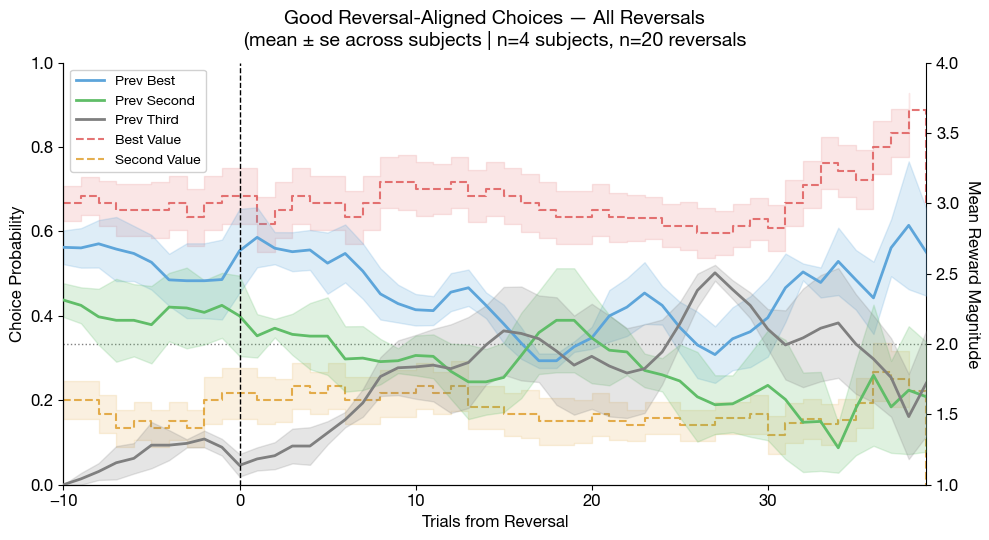

/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:341: RuntimeWarning: Mean of empty slice
  "prev_best_mean":  np.nanmean(stacked["prev_best"],  axis=0),
/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:342: RuntimeWarning: Mean of empty slice
  "prev_sec_mean":   np.nanmean(stacked["prev_sec"],   axis=0),
/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:343: RuntimeWarning: Mean of empty slice
  "prev_third_mean": np.nanmean(stacked["prev_third"], axis=0),
/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:355: RuntimeWarning: Mean of empty slice
  across_mean[k] = np.nanmean(stack, axis=0) if n > 0 else np.full(T, np.nan)
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/

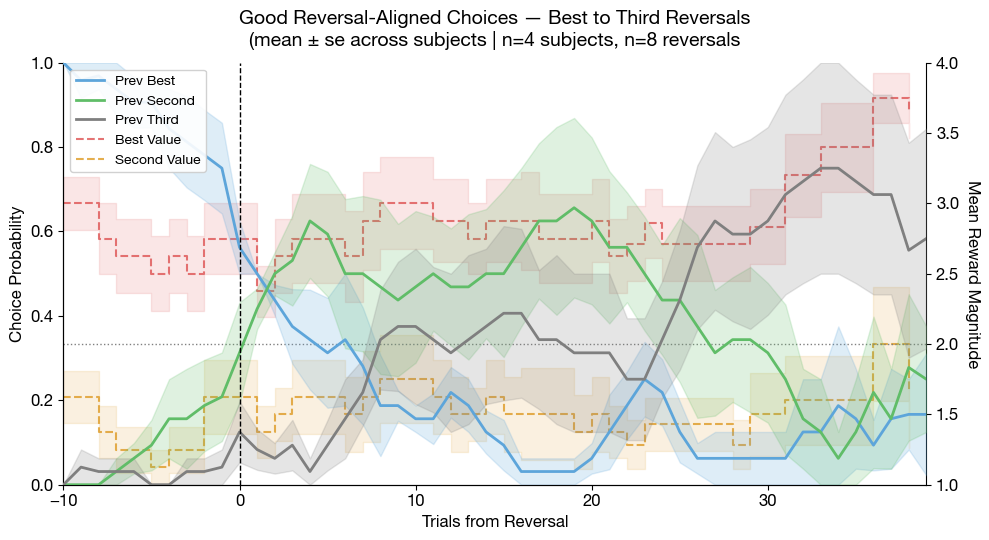

/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:341: RuntimeWarning: Mean of empty slice
  "prev_best_mean":  np.nanmean(stacked["prev_best"],  axis=0),
/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:342: RuntimeWarning: Mean of empty slice
  "prev_sec_mean":   np.nanmean(stacked["prev_sec"],   axis=0),
/var/folders/g7/dhg2tq9173j2cwmlq6jvq28r0000gn/T/ipykernel_46198/1368922626.py:343: RuntimeWarning: Mean of empty slice
  "prev_third_mean": np.nanmean(stacked["prev_third"], axis=0),
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


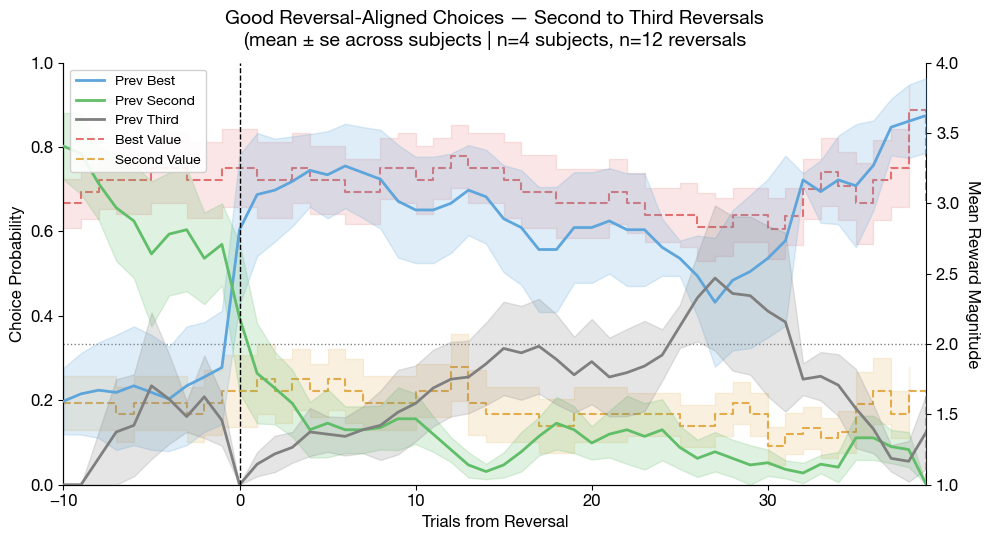

In [10]:
reversal_windows = get_good_reversal_info(subjects_trials, pre=10, post=40, include_first_block=False)

# New: enrich with per-trial magnitudes (mutates reversal_windows in-place)
enrich_reversal_windows_with_magnitudes(reversal_windows, subjects_trials, pre=10, post=40)

for rev_type in ["all", "best_to_third", "second_to_third"]:
    filtered = filter_reversals_by_type(reversal_windows, rev_type)
    x, per_subject, across = get_choice_probs_around_good_reversals_prev_ranks(filtered, pre=10, post=40)
    x, per_subject_sm, across_sm = apply_moving_average(x, per_subject, window=4, mode="centered")
    plot_reversal_choice_probs(x, across_sm, filtered, reversal_type=rev_type, use_moving_avg=True)

In [11]:
"""
value_change_analysis.py
========================
Plots choice probabilities (best, second, third) aligned to increases or
decreases in the true or believed reward magnitude of the rank-1 (best) or
rank-2 (second-best) arm, across all trials in a problem.

Public API
----------
    get_value_change_windows(subjects_trials, rank, direction, pre, post,
                             use_believed, use_believed_rank,
                             rank_preserving_only, rank_swap_only)
    plot_value_change_choice_probs(windows, rank, direction, pre, post,
                                   use_believed, use_believed_rank,
                                   rank_preserving_only, rank_swap_only,
                                   show_individual_mice, save_path)
"""

import warnings
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Style
# ---------------------------------------------------------------------------
mpl.rcParams["font.family"]      = "sans-serif"
mpl.rcParams["font.sans-serif"]  = ["Helvetica Neue", "Helvetica", "Arial"]
mpl.rcParams["xtick.labelsize"]  = 12
mpl.rcParams["ytick.labelsize"]  = 12
mpl.rcParams["axes.labelsize"]   = 12
mpl.rcParams["axes.titlesize"]   = 14

COLOR_MAP = {
    "best":        "#5DA5DA",
    "second":      "#60BD68",
    "third":       "#7f7f7f",
    # arm-identity labels used for rank_swap_only plots
    "prev_best":   "#5DA5DA",
    "prev_second": "#60BD68",
}
LABEL_MAP = {
    "best":        "Best",
    "second":      "Second",
    "third":       "Third",
    "prev_best":   "Prev Best",
    "prev_second": "Prev Second Best",
}


# ---------------------------------------------------------------------------
# Believed rank helper
# ---------------------------------------------------------------------------

def _compute_believed_ranks(choices, reward_magnitudes):
    """
    For each trial, compute the believed rank of the chosen arm by re-ranking
    all arms according to their last-seen magnitudes (believed values).

    Returns a list of "best" / "second" / "third" / None per trial.
    None means at least one arm has never been visited yet.
    """
    last_seen             = {}   # arm -> last observed magnitude
    believed_chosen_ranks = []

    for i, rm in enumerate(reward_magnitudes):
        choice = choices[i]

        if all(arm in last_seen for arm in rm):
            ranked         = sorted(last_seen.items(), key=lambda kv: kv[1], reverse=True)
            rank_of_choice = None
            for ri, (arm, _) in enumerate(ranked):
                if arm == choice:
                    rank_of_choice = ["best", "second", "third"][min(ri, 2)]
                    break
            believed_chosen_ranks.append(rank_of_choice)
        else:
            believed_chosen_ranks.append(None)

        # update AFTER recording so current visit counts for future trials only
        if choice and choice in rm:
            last_seen[choice] = rm[choice]

    return believed_chosen_ranks


# ---------------------------------------------------------------------------
# Window extraction
# ---------------------------------------------------------------------------

def get_value_change_windows(subjects_trials, rank="best", direction="increase",
                              pre=5, post=5, use_believed=False,
                              use_believed_rank=False,
                              rank_preserving_only=False,
                              rank_swap_only=False):
    """
    Find all trials where the magnitude of the rank-1 ("best") or rank-2
    ("second") arm changes in the specified direction, then extract pre/post
    choice probability windows around each event.

    Parameters
    ----------
    subjects_trials      : dict[subject_id -> dict[session_id -> session_data]]
    rank                 : "best" or "second"
    direction            : "increase" or "decrease"
    pre, post            : int, trials before/after the event (event = trial 0)
    use_believed         : bool
    use_believed_rank    : bool
    rank_preserving_only : bool
        Only include events where the target arm keeps its rank after the change.
    rank_swap_only       : bool
        Only include events where the value change causes the best and second-best
        arms to swap identity (i.e. the arm that was best becomes second or vice
        versa). Mutually exclusive with rank_preserving_only.

    Notes
    -----
    rank_preserving_only and rank_swap_only are mutually exclusive. If both are
    True a ValueError is raised.

    Returns
    -------
    dict[subject_id -> list[event_dict]]
    """
    if rank_preserving_only and rank_swap_only:
        raise ValueError("rank_preserving_only and rank_swap_only are mutually exclusive.")

    # A best<->second swap can only be caused by:
    #   - the second arm's value increasing above the best  (rank="second", direction="increase")
    #   - the best arm's value decreasing below the second  (rank="best",   direction="decrease")
    # The other two combos are logically impossible.
    _IMPOSSIBLE_SWAP = {("best", "increase"), ("second", "decrease")}
    if rank_swap_only and (rank, direction) in _IMPOSSIBLE_SWAP:
        raise ValueError(
            f"rank_swap_only=True with rank='{rank}' and direction='{direction}' is "
            f"logically impossible: a {rank}-arm value {direction} cannot cause a "
            f"best<->second swap. Valid swap combos are "
            f"(rank='second', direction='increase') and (rank='best', direction='decrease')."
        )

    rank_idx    = {"best": 0, "second": 1}[rank]
    per_subject = {}

    def _rank_order(mag_dict):
        """Return arm labels sorted by magnitude descending, with deterministic tie-break."""
        return [arm for arm, _ in sorted(mag_dict.items(),
                                         key=lambda kv: (-kv[1], str(kv[0])))]

    def _is_rank_swap(order_before, order_after):
        """
        True if the arms at positions 0 and 1 have swapped between
        order_before and order_after (i.e. best <-> second identity swap).
        """
        if len(order_before) < 2 or len(order_after) < 2:
            return False
        best_before   = order_before[0]
        second_before = order_before[1]
        # A swap means the arm that was best is now second (or lower),
        # and the arm that was second is now best (or higher).
        return (order_after.index(best_before) >= 1 and
                order_after.index(second_before) == 0)

    for subject_id, sessions in subjects_trials.items():
        events = []

        for session_id, sess in sessions.items():
            tv_list = sess.get("trial_variables", [])
            if not tv_list:
                continue
            tv = tv_list[0]

            chosen_ranks      = tv.get("chosen_rank", [])
            reward_magnitudes = tv.get("reward_magnitudes", [])
            choices           = tv.get("choice", [])
            blocks            = tv.get("blocks", [])

            n = min(len(chosen_ranks), len(reward_magnitudes), len(choices))
            if n < 2:
                continue

            if use_believed_rank:
                rank_labels = _compute_believed_ranks(choices[:n], reward_magnitudes[:n])
            else:
                rank_labels = chosen_ranks

            def _same_block(i):
                if len(blocks) < n:
                    return True
                return blocks[i] == blocks[i - 1]

            def _extract_window(i, prev_best_arm=None, prev_second_arm=None):
                """
                Extract pre/post choice label windows around trial i.

                If prev_best_arm and prev_second_arm are provided (rank_swap_only
                mode), labels are fixed arm identities throughout the window:
                  "prev_best"   - mouse chose the arm that was best before swap
                  "prev_second" - mouse chose the arm that was second before swap
                  "third"       - mouse chose the third arm
                Otherwise labels come from rank_labels (current rank at each trial).
                """
                if i - pre < 0 or i + post >= n:
                    return None, None

                def _get(j):
                    if len(blocks) >= n and blocks[j] != blocks[i]:
                        return None
                    if prev_best_arm is not None:
                        c = choices[j]
                        if c == prev_best_arm:
                            return "prev_best"
                        elif c == prev_second_arm:
                            return "prev_second"
                        else:
                            return "third"
                    return rank_labels[j]

                pre_choices  = [_get(j) for j in range(i - pre, i)]
                post_choices = [_get(j) for j in range(i, i + post + 1)]
                return pre_choices, post_choices

            def _apply_rank_filter(order_before, order_after):
                """
                Returns True if the event passes the active rank filter.
                Called only when rank_preserving_only or rank_swap_only is set.
                """
                if rank_preserving_only:
                    target_arm = order_before[rank_idx] if len(order_before) > rank_idx else None
                    new_rank   = order_after.index(target_arm) if target_arm in order_after else None
                    return new_rank == rank_idx
                if rank_swap_only:
                    return _is_rank_swap(order_before, order_after)
                return True   # no filter

            if use_believed:
                last_seen = {}

                for i in range(n):
                    rm     = reward_magnitudes[i]
                    choice = choices[i]

                    sorted_arms = sorted(rm.items(), key=lambda kv: kv[1], reverse=True)
                    target_arm  = (sorted_arms[rank_idx][0]
                                   if len(sorted_arms) > rank_idx else None)

                    if choice == target_arm and target_arm in last_seen:
                        true_mag     = rm[choice]
                        believed_mag = last_seen[target_arm]
                        changed = (true_mag > believed_mag) if direction == "increase" \
                                  else (true_mag < believed_mag)

                        if changed and _same_block(i):
                            passes       = True
                            order_before = None
                            if rank_preserving_only or rank_swap_only:
                                order_before = _rank_order(last_seen)
                                updated      = {**last_seen, choice: true_mag}
                                order_after  = _rank_order(updated)
                                passes       = _apply_rank_filter(order_before, order_after)

                            if passes:
                                pba = (order_before[0]
                                       if rank_swap_only and order_before and len(order_before) > 0
                                       else None)
                                psa = (order_before[1]
                                       if rank_swap_only and order_before and len(order_before) > 1
                                       else None)
                                pre_c, post_c = _extract_window(i,
                                                                 prev_best_arm=pba,
                                                                 prev_second_arm=psa)
                                if pre_c is not None:
                                    events.append({
                                        "subject_id": subject_id,
                                        "session_id": session_id,
                                        "trial_idx":  i,
                                        "pre":        pre_c,
                                        "post":       post_c,
                                    })

                    if choice and choice in rm:
                        last_seen[choice] = rm[choice]

            else:
                # For rank_swap_only the "moving arm" is whichever arm's change
                # can actually cause the overtake:
                #   rank="second"/direction="increase" -> the second arm rises
                #   rank="best"  /direction="decrease" -> the best arm drops
                # In both cases we track the arm at rank_idx BEFORE the change.
                # For non-swap configs we track the arm at rank_idx as before.
                def rank_mag(rm):
                    vals = sorted(rm.values(), reverse=True)
                    return vals[rank_idx] if len(vals) > rank_idx else np.nan

                mags = [rank_mag(reward_magnitudes[i]) for i in range(n)]

                for i in range(1, n):
                    if not _same_block(i):
                        continue

                    if reward_magnitudes[i] == reward_magnitudes[i - 1]:
                        continue

                    prev_mag = mags[i - 1]
                    curr_mag = mags[i]

                    if np.isnan(prev_mag) or np.isnan(curr_mag):
                        continue

                    changed = (curr_mag > prev_mag) if direction == "increase" \
                              else (curr_mag < prev_mag)
                    if not changed:
                        continue

                    passes = True
                    if rank_preserving_only or rank_swap_only:
                        order_before = _rank_order(reward_magnitudes[i - 1])
                        order_after  = _rank_order(reward_magnitudes[i])

                        if rank_swap_only:
                            # Verify the magnitude change is on the arm that
                            # should be moving (rank_idx arm before the change),
                            # not some unrelated arm.
                            moving_arm = order_before[rank_idx] if len(order_before) > rank_idx else None
                            if moving_arm is None:
                                continue
                            arm_prev = reward_magnitudes[i - 1].get(moving_arm, np.nan)
                            arm_curr = reward_magnitudes[i    ].get(moving_arm, np.nan)
                            arm_moved = ((arm_curr > arm_prev) if direction == "increase"
                                         else (arm_curr < arm_prev))
                            if not arm_moved:
                                continue

                        passes = _apply_rank_filter(order_before, order_after)

                    if not passes:
                        continue

                    pba = (order_before[0]
                           if rank_swap_only and len(order_before) > 0 else None)
                    psa = (order_before[1]
                           if rank_swap_only and len(order_before) > 1 else None)
                    pre_c, post_c = _extract_window(i,
                                                     prev_best_arm=pba,
                                                     prev_second_arm=psa)
                    if pre_c is None:
                        continue
                    events.append({
                        "subject_id": subject_id,
                        "session_id": session_id,
                        "trial_idx":  i,
                        "pre":        pre_c,
                        "post":       post_c,
                    })

        if events:
            per_subject[subject_id] = events

    return per_subject


# ---------------------------------------------------------------------------
# Aggregation helper
# ---------------------------------------------------------------------------

def _aggregate_windows(per_subject, pre, post):
    """
    Convert raw choice-rank windows into per-subject mean arrays, then compute
    cross-subject mean and SE.

    Automatically detects whether windows use standard rank labels
    ("best"/"second"/"third") or arm-identity labels
    ("prev_best"/"prev_second"/"third") based on the first event found.
    """
    T = pre + post + 1
    x = np.arange(-pre, post + 1, dtype=float)

    # detect label set from first non-None label in any event
    use_swap_labels = False
    for events in per_subject.values():
        for ev in events:
            for label in ev["pre"] + ev["post"]:
                if label is not None:
                    use_swap_labels = label in ("prev_best", "prev_second")
                    break
            if label is not None:
                break
        break

    ranks = ["prev_best", "prev_second", "third"] if use_swap_labels             else ["best", "second", "third"]

    per_subj_means = {}

    for subj, events in per_subject.items():
        accum = {r: np.full((len(events), T), np.nan) for r in ranks}

        for ei, ev in enumerate(events):
            choices = ev["pre"] + ev["post"]
            for ti, cr in enumerate(choices):
                if cr is None:
                    continue
                for r in ranks:
                    accum[r][ei, ti] = 1.0 if cr == r else 0.0

        per_subj_means[subj] = {r: np.nanmean(accum[r], axis=0) for r in ranks}

    subj_list = list(per_subj_means.keys())
    n         = len(subj_list)

    across_mean, across_se = {}, {}
    for r in ranks:
        if subj_list:
            stack          = np.vstack([per_subj_means[s][r] for s in subj_list])
            across_mean[r] = np.nanmean(stack, axis=0)
            across_se[r]   = (np.nanstd(stack, axis=0, ddof=1) / np.sqrt(n)
                               if n > 1 else np.zeros(T))
        else:
            across_mean[r] = np.full(T, np.nan)
            across_se[r]   = np.full(T, np.nan)

    across = {
        "mean":         across_mean,
        "se":           across_se,
        "num_subjects": n,
        "num_events":   sum(len(evs) for evs in per_subject.values()),
    }

    return x, per_subj_means, across


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_value_change_choice_probs(
    windows,
    rank="best",
    direction="increase",
    pre=5,
    post=5,
    use_believed=False,
    use_believed_rank=False,
    rank_preserving_only=False,
    rank_swap_only=False,
    show_individual_mice=False,
    save_path=None,
):
    """
    Plot choice probabilities (best / second / third) aligned to a value-change
    event.

    Parameters
    ----------
    rank_preserving_only : bool -- event kept only if target arm retains its rank
    rank_swap_only       : bool -- event kept only if best/second arms swap identity
    (all other parameters as before)
    """
    rank_label  = "Best" if rank == "best" else "Second-Best"
    dir_label   = "Increase" if direction == "increase" else "Decrease"
    value_label = "Believed" if use_believed else "True"
    rank_suffix = " (Believed Rank)" if use_believed_rank else ""

    if rank_preserving_only:
        filter_suffix = " [Rank-Preserving Only]"
    elif rank_swap_only:
        filter_suffix = " [Rank-Swap Only]"
    else:
        filter_suffix = ""

    x, per_subj_means, across = _aggregate_windows(windows, pre, post)
    n_subj   = across["num_subjects"]
    n_events = across["num_events"]

    # use arm-identity label set for swap plots, standard labels otherwise
    rank_keys = (["prev_best", "prev_second", "third"] if rank_swap_only
                 else ["best", "second", "third"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for r in rank_keys:
        mean = across["mean"][r]
        se   = across["se"][r]
        col  = COLOR_MAP[r]

        if show_individual_mice:
            for subj_means in per_subj_means.values():
                y_subj = subj_means[r]
                m = np.isfinite(y_subj)
                if m.any():
                    ax.plot(x[m], y_subj[m], color="gray", lw=0.8, alpha=0.4, zorder=1)

        m = np.isfinite(mean)
        if m.any():
            ax.plot(x[m], mean[m], color=col, lw=2.2, label=LABEL_MAP[r], zorder=3)
            ax.fill_between(x, mean - se, mean + se, where=m,
                            alpha=0.2, color=col, zorder=2)

    ax.axvline(0,     color="black", ls="--", lw=1, zorder=4)
    ax.axhline(1 / 3, color="gray",  ls=":",  lw=1, zorder=1)
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(0, 1)
    ax.set_xlabel("Trials from Value Change", fontsize=12)
    ax.set_ylabel("Choice Probability",       fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper right", fontsize=10, framealpha=0.9)

    title = (
        f"Choice Probabilities Aligned to {rank_label} {value_label} Value"
        f" {dir_label}{rank_suffix}{filter_suffix}\n"
        f"(mean +/- se across subjects | "
        f"n={n_subj} subjects, n={n_events} events)"
    )
    ax.set_title(title, pad=12)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        plt.tight_layout()

    if save_path:
        from pathlib import Path
        base = Path(save_path)
        base.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(base) + ".pdf", bbox_inches="tight")
        fig.savefig(str(base) + ".png", dpi=300, bbox_inches="tight")
    else:
        plt.show()

    plt.close(fig)

In [12]:
"""
value_change_analysis.py
========================
Plots choice probabilities (best, second, third) aligned to increases or
decreases in the true or believed reward magnitude of the rank-1 (best) or
rank-2 (second-best) arm, across all trials in a problem.

Public API
----------
    get_value_change_windows(subjects_trials, rank, direction, pre, post,
                             use_believed, use_believed_rank,
                             rank_preserving_only, rank_swap_only)
    plot_value_change_choice_probs(windows, rank, direction, pre, post,
                                   use_believed, use_believed_rank,
                                   rank_preserving_only, rank_swap_only,
                                   show_individual_mice, save_path)
"""

import warnings
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Style
# ---------------------------------------------------------------------------
mpl.rcParams["font.family"]      = "sans-serif"
mpl.rcParams["font.sans-serif"]  = ["Helvetica Neue", "Helvetica", "Arial"]
mpl.rcParams["xtick.labelsize"]  = 12
mpl.rcParams["ytick.labelsize"]  = 12
mpl.rcParams["axes.labelsize"]   = 12
mpl.rcParams["axes.titlesize"]   = 14

COLOR_MAP = {
    "best":        "#5DA5DA",
    "second":      "#60BD68",
    "third":       "#7f7f7f",
    # arm-identity labels used for rank_swap_only plots
    "prev_best":   "#5DA5DA",
    "prev_second": "#60BD68",
}
LABEL_MAP = {
    "best":        "Best",
    "second":      "Second",
    "third":       "Third",
    "prev_best":   "Prev Best",
    "prev_second": "Prev Second Best",
}


# ---------------------------------------------------------------------------
# Believed rank helper
# ---------------------------------------------------------------------------

def _compute_believed_ranks(choices, reward_magnitudes):
    """
    For each trial, compute the believed rank of the chosen arm by re-ranking
    all arms according to their last-seen magnitudes (believed values).

    Returns a list of "best" / "second" / "third" / None per trial.
    None means at least one arm has never been visited yet.
    """
    last_seen             = {}   # arm -> last observed magnitude
    believed_chosen_ranks = []

    for i, rm in enumerate(reward_magnitudes):
        choice = choices[i]

        if all(arm in last_seen for arm in rm):
            ranked         = sorted(last_seen.items(), key=lambda kv: kv[1], reverse=True)
            rank_of_choice = None
            for ri, (arm, _) in enumerate(ranked):
                if arm == choice:
                    rank_of_choice = ["best", "second", "third"][min(ri, 2)]
                    break
            believed_chosen_ranks.append(rank_of_choice)
        else:
            believed_chosen_ranks.append(None)

        # update AFTER recording so current visit counts for future trials only
        if choice and choice in rm:
            last_seen[choice] = rm[choice]

    return believed_chosen_ranks


# ---------------------------------------------------------------------------
# Window extraction
# ---------------------------------------------------------------------------

def get_value_change_windows(subjects_trials, rank="best", direction="increase",
                              pre=5, post=5, use_believed=False,
                              use_believed_rank=False,
                              rank_preserving_only=False,
                              rank_swap_only=False):
    """
    Find all trials where the magnitude of the rank-1 ("best") or rank-2
    ("second") arm changes in the specified direction, then extract pre/post
    choice probability windows around each event.

    Parameters
    ----------
    subjects_trials      : dict[subject_id -> dict[session_id -> session_data]]
    rank                 : "best" or "second"
    direction            : "increase" or "decrease"
    pre, post            : int, trials before/after the event (event = trial 0)
    use_believed         : bool
    use_believed_rank    : bool
    rank_preserving_only : bool
        Only include events where the target arm keeps its rank after the change.
    rank_swap_only       : bool
        Only include events where the value change causes the best and second-best
        arms to swap identity (i.e. the arm that was best becomes second or vice
        versa). Mutually exclusive with rank_preserving_only.

    Notes
    -----
    rank_preserving_only and rank_swap_only are mutually exclusive. If both are
    True a ValueError is raised.

    Returns
    -------
    dict[subject_id -> list[event_dict]]
    """
    if rank_preserving_only and rank_swap_only:
        raise ValueError("rank_preserving_only and rank_swap_only are mutually exclusive.")

    # A best<->second swap can only be caused by:
    #   - the second arm's value increasing above the best  (rank="second", direction="increase")
    #   - the best arm's value decreasing below the second  (rank="best",   direction="decrease")
    # The other two combos are logically impossible.
    _IMPOSSIBLE_SWAP = {("best", "increase"), ("second", "decrease")}
    if rank_swap_only and (rank, direction) in _IMPOSSIBLE_SWAP:
        raise ValueError(
            f"rank_swap_only=True with rank='{rank}' and direction='{direction}' is "
            f"logically impossible: a {rank}-arm value {direction} cannot cause a "
            f"best<->second swap. Valid swap combos are "
            f"(rank='second', direction='increase') and (rank='best', direction='decrease')."
        )

    rank_idx    = {"best": 0, "second": 1}[rank]
    per_subject = {}

    def _rank_order(mag_dict):
        """Return arm labels sorted by magnitude descending, with deterministic tie-break."""
        return [arm for arm, _ in sorted(mag_dict.items(),
                                         key=lambda kv: (-kv[1], str(kv[0])))]

    def _is_rank_swap(order_before, order_after):
        """
        True if the arms at positions 0 and 1 have swapped between
        order_before and order_after (i.e. best <-> second identity swap).
        """
        if len(order_before) < 2 or len(order_after) < 2:
            return False
        best_before   = order_before[0]
        second_before = order_before[1]
        # A swap means the arm that was best is now second (or lower),
        # and the arm that was second is now best (or higher).
        return (order_after.index(best_before) >= 1 and
                order_after.index(second_before) == 0)

    for subject_id, sessions in subjects_trials.items():
        events = []

        for session_id, sess in sessions.items():
            tv_list = sess.get("trial_variables", [])
            if not tv_list:
                continue
            tv = tv_list[0]

            chosen_ranks      = tv.get("chosen_rank", [])
            reward_magnitudes = tv.get("reward_magnitudes", [])
            choices           = tv.get("choice", [])
            blocks            = tv.get("blocks", [])

            n = min(len(chosen_ranks), len(reward_magnitudes), len(choices))
            if n < 2:
                continue

            if use_believed_rank:
                rank_labels = _compute_believed_ranks(choices[:n], reward_magnitudes[:n])
            else:
                rank_labels = chosen_ranks

            def _same_block(i):
                if len(blocks) < n:
                    return True
                return blocks[i] == blocks[i - 1]

            def _extract_window(i, prev_best_arm=None, prev_second_arm=None):
                """
                Extract pre/post choice label windows around trial i.

                The window is anchored at i-1 (the last trial of the old block),
                so that:
                  t=0  -> trial i-1  (last trial before the value change)
                  t=1  -> trial i    (first trial with new information)

                If prev_best_arm and prev_second_arm are provided (rank_swap_only
                mode), labels are fixed arm identities throughout the window:
                  "prev_best"   - mouse chose the arm that was best before swap
                  "prev_second" - mouse chose the arm that was second before swap
                  "third"       - mouse chose the third arm
                Otherwise labels come from rank_labels (current rank at each trial).
                """
                anchor = i - 1   # t=0 is the last trial of the old block
                if anchor - pre < 0 or anchor + post >= n:
                    return None, None

                # block-filter uses the event trial i to identify the new block;
                # trials in the pre window belong to the old block (i-1's block)
                old_block = blocks[anchor] if len(blocks) >= n else None
                new_block = blocks[i]      if len(blocks) >= n else None

                def _get(j):
                    if len(blocks) >= n:
                        # pre-anchor trials must be in old block,
                        # post-anchor trials (j >= i) must be in new block
                        expected = new_block if j >= i else old_block
                        if blocks[j] != expected:
                            return None
                    if prev_best_arm is not None:
                        c = choices[j]
                        if c == prev_best_arm:
                            return "prev_best"
                        elif c == prev_second_arm:
                            return "prev_second"
                        else:
                            return "third"
                    return rank_labels[j]

                pre_choices  = [_get(j) for j in range(anchor - pre, anchor + 1)]
                post_choices = [_get(j) for j in range(i, anchor + post + 1)]
                return pre_choices, post_choices

            def _apply_rank_filter(order_before, order_after):
                """
                Returns True if the event passes the active rank filter.
                Called only when rank_preserving_only or rank_swap_only is set.
                """
                if rank_preserving_only:
                    target_arm = order_before[rank_idx] if len(order_before) > rank_idx else None
                    new_rank   = order_after.index(target_arm) if target_arm in order_after else None
                    return new_rank == rank_idx
                if rank_swap_only:
                    return _is_rank_swap(order_before, order_after)
                return True   # no filter

            if use_believed:
                last_seen = {}

                for i in range(n):
                    rm     = reward_magnitudes[i]
                    choice = choices[i]

                    sorted_arms = sorted(rm.items(), key=lambda kv: kv[1], reverse=True)
                    target_arm  = (sorted_arms[rank_idx][0]
                                   if len(sorted_arms) > rank_idx else None)

                    if choice == target_arm and target_arm in last_seen:
                        true_mag     = rm[choice]
                        believed_mag = last_seen[target_arm]
                        changed = (true_mag > believed_mag) if direction == "increase" \
                                  else (true_mag < believed_mag)

                        if changed and _same_block(i):
                            passes       = True
                            order_before = None
                            if rank_preserving_only or rank_swap_only:
                                order_before = _rank_order(last_seen)
                                updated      = {**last_seen, choice: true_mag}
                                order_after  = _rank_order(updated)
                                passes       = _apply_rank_filter(order_before, order_after)

                            if passes:
                                pba = (order_before[0]
                                       if rank_swap_only and order_before and len(order_before) > 0
                                       else None)
                                psa = (order_before[1]
                                       if rank_swap_only and order_before and len(order_before) > 1
                                       else None)
                                pre_c, post_c = _extract_window(i,
                                                                 prev_best_arm=pba,
                                                                 prev_second_arm=psa)
                                if pre_c is not None:
                                    events.append({
                                        "subject_id": subject_id,
                                        "session_id": session_id,
                                        "trial_idx":  i,
                                        "pre":        pre_c,
                                        "post":       post_c,
                                    })

                    if choice and choice in rm:
                        last_seen[choice] = rm[choice]

            else:
                # For rank_swap_only the "moving arm" is whichever arm's change
                # can actually cause the overtake:
                #   rank="second"/direction="increase" -> the second arm rises
                #   rank="best"  /direction="decrease" -> the best arm drops
                # In both cases we track the arm at rank_idx BEFORE the change.
                # For non-swap configs we track the arm at rank_idx as before.
                def rank_mag(rm):
                    vals = sorted(rm.values(), reverse=True)
                    return vals[rank_idx] if len(vals) > rank_idx else np.nan

                mags = [rank_mag(reward_magnitudes[i]) for i in range(n)]

                for i in range(1, n):
                    if not _same_block(i):
                        continue

                    if reward_magnitudes[i] == reward_magnitudes[i - 1]:
                        continue

                    prev_mag = mags[i - 1]
                    curr_mag = mags[i]

                    if np.isnan(prev_mag) or np.isnan(curr_mag):
                        continue

                    changed = (curr_mag > prev_mag) if direction == "increase" \
                              else (curr_mag < prev_mag)
                    if not changed:
                        continue

                    passes = True
                    if rank_preserving_only or rank_swap_only:
                        order_before = _rank_order(reward_magnitudes[i - 1])
                        order_after  = _rank_order(reward_magnitudes[i])

                        if rank_swap_only:
                            # Verify the magnitude change is on the arm that
                            # should be moving (rank_idx arm before the change),
                            # not some unrelated arm.
                            moving_arm = order_before[rank_idx] if len(order_before) > rank_idx else None
                            if moving_arm is None:
                                continue
                            arm_prev = reward_magnitudes[i - 1].get(moving_arm, np.nan)
                            arm_curr = reward_magnitudes[i    ].get(moving_arm, np.nan)
                            arm_moved = ((arm_curr > arm_prev) if direction == "increase"
                                         else (arm_curr < arm_prev))
                            if not arm_moved:
                                continue

                        passes = _apply_rank_filter(order_before, order_after)

                    if not passes:
                        continue

                    pba = (order_before[0]
                           if rank_swap_only and len(order_before) > 0 else None)
                    psa = (order_before[1]
                           if rank_swap_only and len(order_before) > 1 else None)
                    pre_c, post_c = _extract_window(i,
                                                     prev_best_arm=pba,
                                                     prev_second_arm=psa)
                    if pre_c is None:
                        continue
                    events.append({
                        "subject_id": subject_id,
                        "session_id": session_id,
                        "trial_idx":  i,
                        "pre":        pre_c,
                        "post":       post_c,
                    })

        if events:
            per_subject[subject_id] = events

    return per_subject


# ---------------------------------------------------------------------------
# Aggregation helper
# ---------------------------------------------------------------------------

def _aggregate_windows(per_subject, pre, post):
    """
    Convert raw choice-rank windows into per-subject mean arrays, then compute
    cross-subject mean and SE.

    Automatically detects whether windows use standard rank labels
    ("best"/"second"/"third") or arm-identity labels
    ("prev_best"/"prev_second"/"third") based on the first event found.
    """
    T = pre + post + 1
    x = np.arange(-pre, post + 1, dtype=float)

    # detect label set from first non-None label in any event
    use_swap_labels = False
    for events in per_subject.values():
        for ev in events:
            for label in ev["pre"] + ev["post"]:
                if label is not None:
                    use_swap_labels = label in ("prev_best", "prev_second")
                    break
            if label is not None:
                break
        break

    ranks = ["prev_best", "prev_second", "third"] if use_swap_labels             else ["best", "second", "third"]

    per_subj_means = {}

    for subj, events in per_subject.items():
        accum = {r: np.full((len(events), T), np.nan) for r in ranks}

        for ei, ev in enumerate(events):
            choices = ev["pre"] + ev["post"]
            for ti, cr in enumerate(choices):
                if cr is None:
                    continue
                for r in ranks:
                    accum[r][ei, ti] = 1.0 if cr == r else 0.0

        per_subj_means[subj] = {r: np.nanmean(accum[r], axis=0) for r in ranks}

    subj_list = list(per_subj_means.keys())
    n         = len(subj_list)

    across_mean, across_se = {}, {}
    for r in ranks:
        if subj_list:
            stack          = np.vstack([per_subj_means[s][r] for s in subj_list])
            across_mean[r] = np.nanmean(stack, axis=0)
            across_se[r]   = (np.nanstd(stack, axis=0, ddof=1) / np.sqrt(n)
                               if n > 1 else np.zeros(T))
        else:
            across_mean[r] = np.full(T, np.nan)
            across_se[r]   = np.full(T, np.nan)

    across = {
        "mean":         across_mean,
        "se":           across_se,
        "num_subjects": n,
        "num_events":   sum(len(evs) for evs in per_subject.values()),
    }

    return x, per_subj_means, across


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_value_change_choice_probs(
    windows,
    rank="best",
    direction="increase",
    pre=5,
    post=5,
    use_believed=False,
    use_believed_rank=False,
    rank_preserving_only=False,
    rank_swap_only=False,
    show_individual_mice=False,
    save_path=None,
):
    """
    Plot choice probabilities (best / second / third) aligned to a value-change
    event.

    Parameters
    ----------
    rank_preserving_only : bool -- event kept only if target arm retains its rank
    rank_swap_only       : bool -- event kept only if best/second arms swap identity
    (all other parameters as before)
    """
    rank_label  = "Best" if rank == "best" else "Second-Best"
    dir_label   = "Increase" if direction == "increase" else "Decrease"
    value_label = "Believed" if use_believed else "True"
    rank_suffix = " (Believed Rank)" if use_believed_rank else ""

    if rank_preserving_only:
        filter_suffix = " [Rank-Preserving Only]"
    elif rank_swap_only:
        filter_suffix = " [Rank-Swap Only]"
    else:
        filter_suffix = ""

    x, per_subj_means, across = _aggregate_windows(windows, pre, post)
    n_subj   = across["num_subjects"]
    n_events = across["num_events"]

    # use arm-identity label set for swap plots, standard labels otherwise
    rank_keys = (["prev_best", "prev_second", "third"] if rank_swap_only
                 else ["best", "second", "third"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for r in rank_keys:
        mean = across["mean"][r]
        se   = across["se"][r]
        col  = COLOR_MAP[r]

        if show_individual_mice:
            for subj_means in per_subj_means.values():
                y_subj = subj_means[r]
                m = np.isfinite(y_subj)
                if m.any():
                    ax.plot(x[m], y_subj[m], color="gray", lw=0.8, alpha=0.4, zorder=1)

        m = np.isfinite(mean)
        if m.any():
            ax.plot(x[m], mean[m], color=col, lw=2.2, label=LABEL_MAP[r], zorder=3)
            ax.fill_between(x, mean - se, mean + se, where=m,
                            alpha=0.2, color=col, zorder=2)

    ax.axvline(0,     color="black", ls="--", lw=1, zorder=4)
    ax.axhline(1 / 3, color="gray",  ls=":",  lw=1, zorder=1)
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(0, 1)
    ax.set_xlabel("Trials from Value Change (0 = last pre-change trial)", fontsize=12)
    ax.set_ylabel("Choice Probability",       fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper right", fontsize=10, framealpha=0.9)

    title = (
        f"Choice Probabilities Aligned to {rank_label} {value_label} Value"
        f" {dir_label}{rank_suffix}{filter_suffix}\n"
        f"(mean +/- se across subjects | "
        f"n={n_subj} subjects, n={n_events} events)"
    )
    ax.set_title(title, pad=12)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        plt.tight_layout()

    if save_path:
        from pathlib import Path
        base = Path(save_path)
        base.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(base) + ".pdf", bbox_inches="tight")
        fig.savefig(str(base) + ".png", dpi=300, bbox_inches="tight")
    else:
        plt.show()

    plt.close(fig)


In [13]:
subjects_trials = subject_trials_by_value_problem[6]

# Show inline
run_all_value_change_plots(subjects_trials, pre=5, post=10)

NameError: name 'run_all_value_change_plots' is not defined

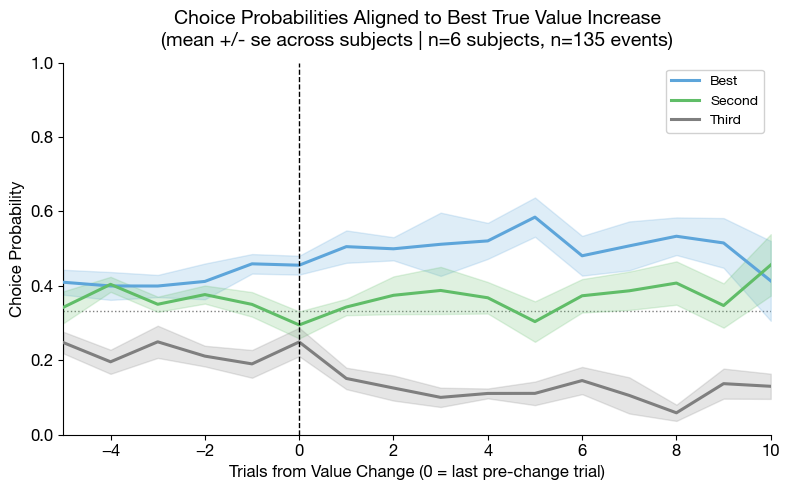

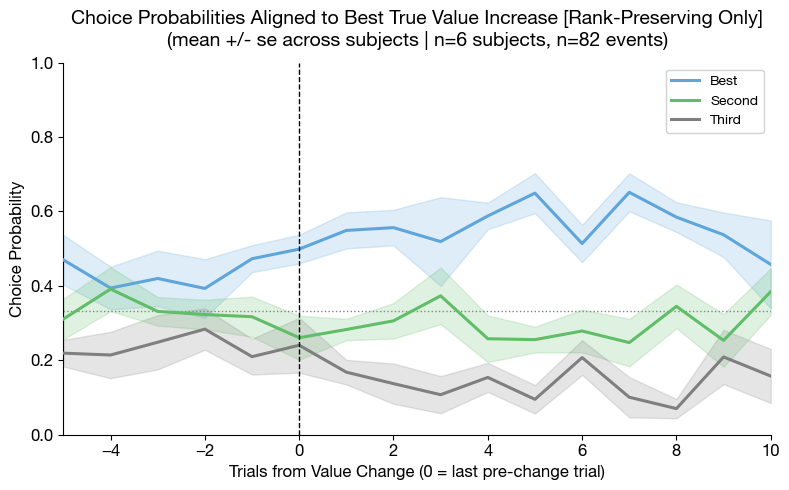

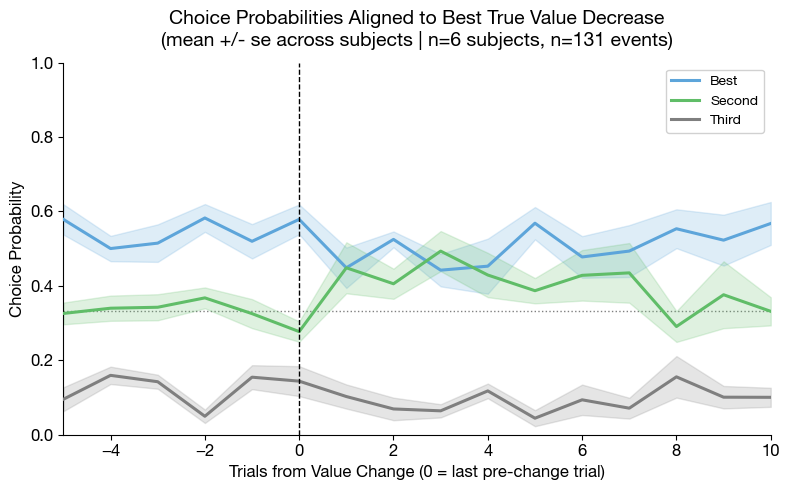

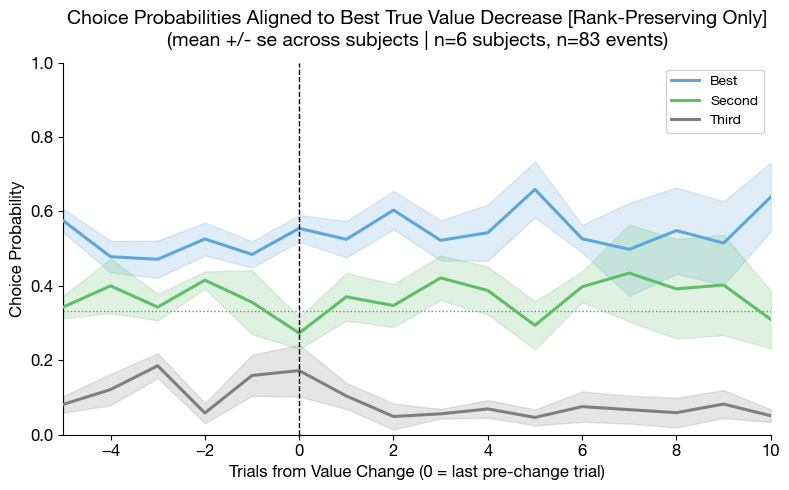

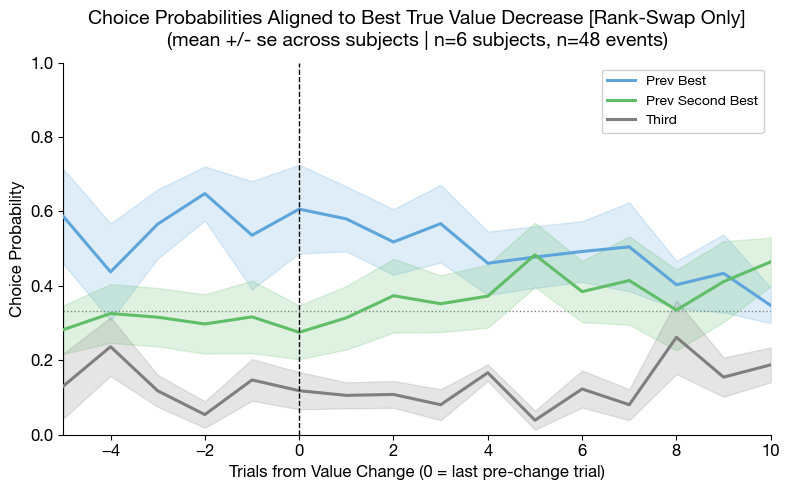

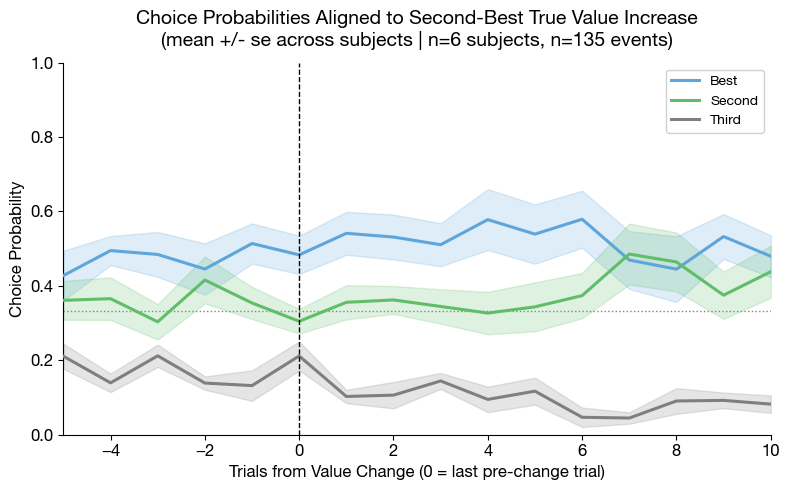

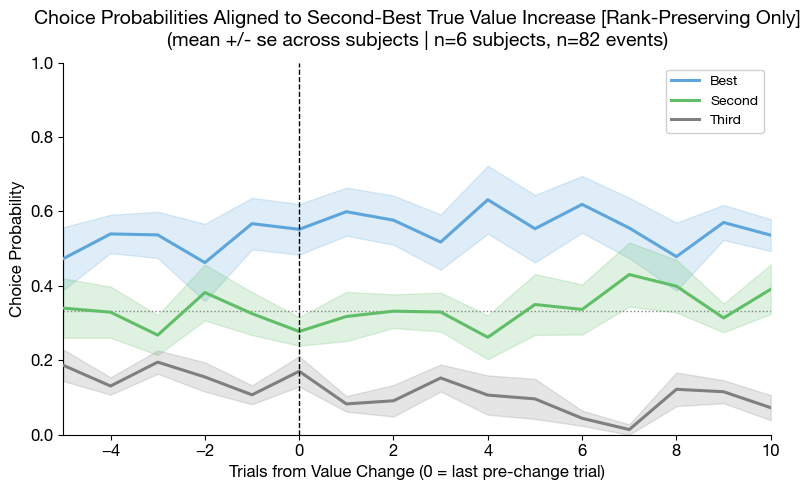

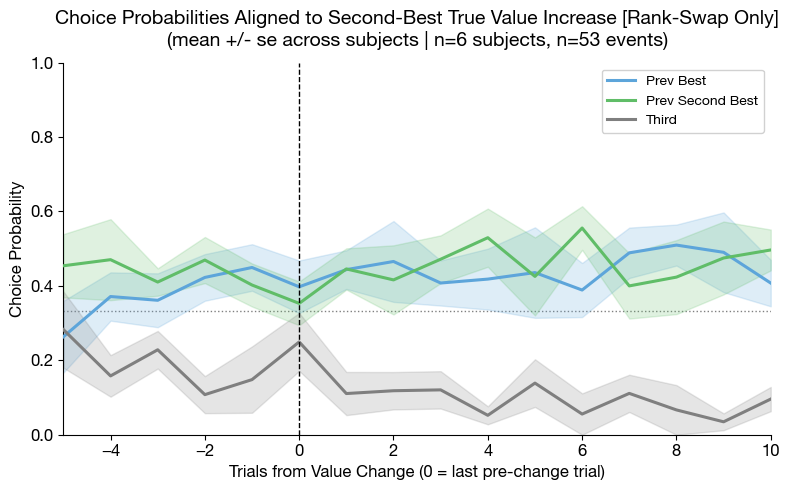

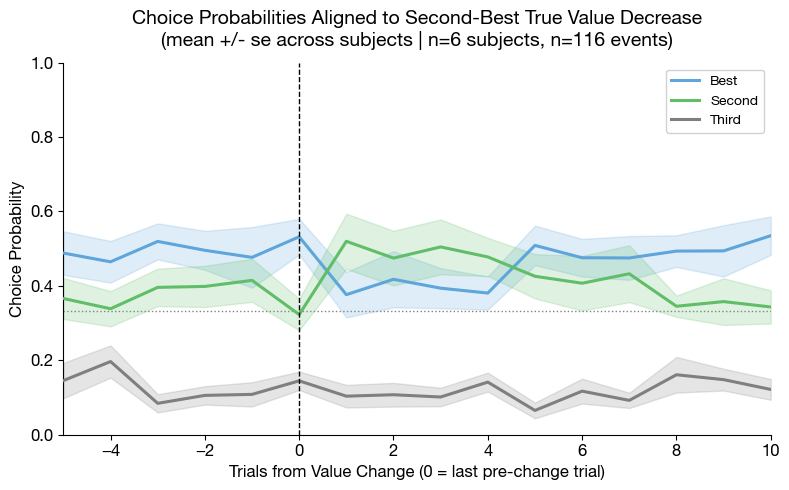

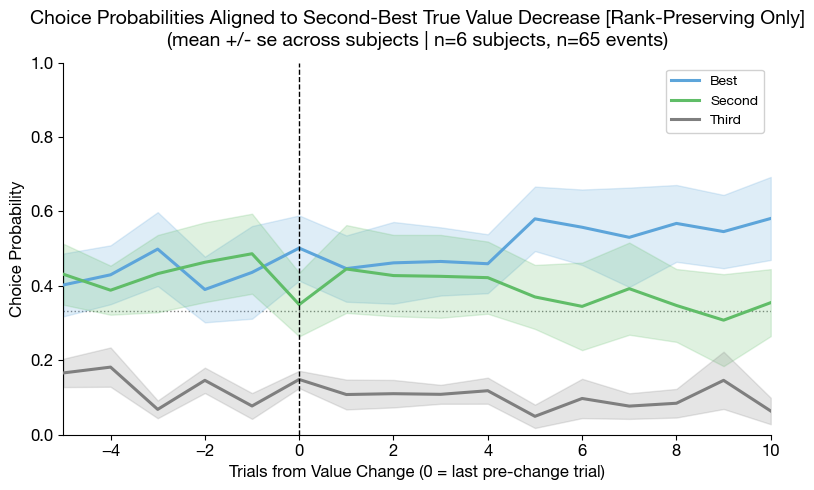

In [ ]:
def flatten_subjects_trials(subjects_trials):
    """
    Convert:
        {problem_id: {animal_id: {session_id: session_data}}}
    to:
        {animal_id: {session_id: session_data}}

    Sessions are prefixed with problem_id to avoid collisions,
    e.g. 'prob1__ses-46_date-20260228'.
    """
    flat = {}
    for problem_id, animals in subjects_trials.items():
        for animal_id, sessions in animals.items():
            if animal_id not in flat:
                flat[animal_id] = {}
            for session_id, session_data in sessions.items():
                flat_key = f"prob{problem_id}__{session_id}"
                flat[animal_id][flat_key] = session_data
    return flat

# Usage:
subjects_trials_flat = flatten_subjects_trials(subjects_trials)
run_all_value_change_plots(subjects_trials_flat, pre=5, post=10)